In [1]:
# PHYSICS DEGREE THESIS

In [2]:
!pip install numpy scipy matplotlib networkx scikit-learn pandas

In [5]:
# signals.py
import numpy as np
from scipy.signal import firwin, filtfilt, hilbert

def band_defs():
    # Puedes ajustar bandas aquí y que se propaguen al resto
    return {
        "delta": (1.0, 4.0),
        "theta": (4.0, 8.0),
        "alpha": (8.0, 12.0),
        "beta":  (13.0, 30.0),
        "gamma": (30.0, 48.0),
    }

def design_fir_bandpass(fs, f_lo, f_hi, numtaps=801, transition=0.15):
    """
    FIR lineal en fase. 'transition' es fracción del ancho de banda para alisar bordes.
    """
    nyq = fs / 2.0
    bw = f_hi - f_lo
    lo = max(0.001, f_lo - transition * bw)
    hi = min(nyq - 0.001, f_hi + transition * bw)
    taps = firwin(numtaps, [lo/nyq, hi/nyq], pass_zero=False, window="hamming")
    return taps

def bandpass_filt(X, fs, band, numtaps=801, transition=0.15, edge_trim=None):
    """
    X: (n_roi, n_time) o (n_time,) ndarray
    Devuelve X_filtrado del mismo shape. Si edge_trim no es None, trimea extremos.
    """
    X = np.asarray(X)
    f_lo, f_hi = band
    taps = design_fir_bandpass(fs, f_lo, f_hi, numtaps=numtaps, transition=transition)
    if X.ndim == 1:
        Y = filtfilt(taps, [1.0], X, axis=-1, padtype="odd")
    else:
        Y = filtfilt(taps, [1.0], X, axis=-1, padtype="odd")
    if edge_trim is not None and edge_trim > 0:
        if X.ndim == 1:
            Y = Y[edge_trim:-edge_trim]
        else:
            Y = Y[:, edge_trim:-edge_trim]
    return Y

def analytic_signal(X):
    """
    Señal analítica por Hilbert. X: (..., n_time) -> complejo del mismo shape.
    """
    return hilbert(X, axis=-1)

def phase_and_envelope(X_band):
    """
    X_band: (n_roi, n_time) filtrado de banda.
    Devuelve: phase (rad), envelope (>=0), ambos (n_roi, n_time).
    """
    Xa = analytic_signal(X_band)
    return np.angle(Xa), np.abs(Xa)

def window_indices(n_time, fs, win_length_s=4.0, step_s=2.0):
    """
    Devuelve lista de (start, stop) para ventanas deslizantes.
    """
    L = int(round(win_length_s * fs))
    S = int(round(step_s * fs))
    idx = []
    start = 0
    while start + L <= n_time:
        idx.append((start, start + L))
        start += S
    return idx

def demean_detrend(X):
    """
    Demean por ROI; puedes extender con detrend si quieres.
    """
    X = np.asarray(X, float)
    X = X - X.mean(axis=-1, keepdims=True)
    return X

In [7]:
# connectivity.py
import numpy as np
from scipy.signal import hilbert
#from .signals import bandpass_filt, phase_and_envelope, window_indices

def _ensure_2d(X):
    X = np.asarray(X)
    if X.ndim == 1:
        X = X[None, :]
    return X

def plv_matrix(X, fs, band, edge_trim=None, window_s=None, step_s=None):
    """
    PLV par-a-par tras filtrado en banda.
    X: (n_roi, n_time)
    Devuelve: (n_roi, n_roi) con diagonal 0 y simétrica.
    """
    X = _ensure_2d(X)
    Xb = bandpass_filt(X, fs, band, edge_trim=edge_trim)
    phase, _ = phase_and_envelope(Xb)  # (N,T)
    N, T = phase.shape
    if window_s is None:
        # una sola estimación
        diffs = phase[:, None, :] - phase[None, :, :]  # (N,N,T)
        C = np.abs(np.exp(1j * diffs).mean(axis=-1))
    else:
        # promedia sobre ventanas
        idx = window_indices(T, fs, window_s, step_s or (window_s/2))
        acc = np.zeros((N, N), dtype=float)
        for a, b in idx:
            ph = phase[:, a:b]
            diffs = ph[:, None, :] - ph[None, :, :]
            acc += np.abs(np.exp(1j * diffs).mean(axis=-1))
        C = acc / max(1, len(idx))
    # limpiar diagonal y simetrizar
    np.fill_diagonal(C, 0.0)
    C = 0.5 * (C + C.T)
    return C

def aec_matrix(X, fs, band, edge_trim=None, window_s=None, step_s=None, demean=True):
    """
    AEC por correlación de envolventes tras Hilbert.
    """
    X = _ensure_2d(X)
    Xb = bandpass_filt(X, fs, band, edge_trim=edge_trim)
    _, env = phase_and_envelope(Xb)  # (N,T)
    if demean:
        env = env - env.mean(axis=-1, keepdims=True)
    if window_s is None:
        C = np.corrcoef(env)
    else:
        N, T = env.shape
        idx = window_indices(T, fs, window_s, step_s or (window_s/2))
        acc = np.zeros((N, N), dtype=float)
        for a, b in idx:
            Cw = np.corrcoef(env[:, a:b])
            acc += Cw
        C = acc / max(1, len(idx))
    np.fill_diagonal(C, 0.0)
    C = np.clip(0.5*(C + C.T), -1.0, 1.0)
    return C

def _orth_component(xa, ya):
    """
    Componente ortogonal de ya respecto a xa, estilo Hipp et al.
    xa, ya: (T,) complejas (señales analíticas)
    Devuelve y_perp (T,) real (usamos parte imaginaria como componente ortogonal).
    """
    return np.imag(ya * np.exp(-1j * np.angle(xa)))

def aec_orth_matrix(X, fs, band, edge_trim=None, window_s=None, step_s=None, demean=True, symmetric=True):
    """
    AEC ortogonalizada: proyección simétrica y correlación de envolventes.
    """
    X = _ensure_2d(X)
    Xb = bandpass_filt(X, fs, band, edge_trim=edge_trim)
    Xa = Xb + 1j * np.imag(np.fft.ifft(np.fft.fft(Xb) * 1j))  
    Xa = hilbert(Xb, axis=-1)
    N, T = Xa.shape
    env = np.abs(Xa)
    if demean:
        env = env - env.mean(axis=-1, keepdims=True)

    C = np.zeros((N, N), dtype=float)
    # vectorizado por bloques (par-a-par puede ser costoso para N~100; pero está OK)
    for i in range(N):
        for j in range(i+1, N):
            yi_perp = _orth_component(Xa[i], Xa[j])
            xi_perp = _orth_component(Xa[j], Xa[i])
            Ai = env[i]
            Aj_perp = np.abs(yi_perp)
            Aj = env[j]
            Ai_perp = np.abs(xi_perp)
            # correlaciones
            rij1 = np.corrcoef(Ai, Aj_perp)[0, 1]
            rij2 = np.corrcoef(Aj, Ai_perp)[0, 1]
            Cij = 0.5*(rij1 + rij2) if symmetric else rij1
            C[i, j] = C[j, i] = Cij
    np.fill_diagonal(C, 0.0)
    C = np.clip(C, -1.0, 1.0)
    return C



In [18]:
# viz.py
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

def plot_matrix(C, title="", vmin=None, vmax=None, cmap="viridis", outfile=None):
    R = C.shape[0]
    plt.figure(figsize=(5,4))
    im = plt.imshow(C, vmin=vmin, vmax=vmax, cmap=cmap, origin="lower")
    plt.colorbar(im, fraction=0.046, pad=0.04)
    plt.title(title)
    plt.xlabel("ROI")
    plt.ylabel("ROI")
    plt.tight_layout()
    if outfile:
        plt.savefig(outfile, dpi=300, bbox_inches="tight")
    plt.close()

def threshold_matrix(C, mask=None, thr=None, keep="upper"):
    """ Devuelve lista de (i,j,w) con aristas umbralizadas. """
    R = C.shape[0]
    iu = np.triu_indices(R, 1) if keep == "upper" else np.tril_indices(R, -1)
    W = C[iu]
    if mask is not None:
        keep_idx = mask[iu]
    elif thr is not None:
        keep_idx = (W >= thr)
    else:
        keep_idx = np.ones_like(W, dtype=bool)
    edges = [(int(iu[0][k]), int(iu[1][k]), float(W[k])) for k in np.where(keep_idx)[0]]
    return edges

def graph_from_matrix(C, roi_labels=None, mask=None, thr=None, layout="circular", title="", outfile=None):
    edges = threshold_matrix(C, mask=mask, thr=thr)
    G = nx.Graph()
    R = C.shape[0]
    for n in range(R):
        name = roi_labels[n] if roi_labels is not None else n
        G.add_node(n, label=name, strength=float(np.sum(C[n])))
    for i, j, w in edges:
        G.add_edge(i, j, weight=w)
    if layout == "circular":
        pos = nx.circular_layout(G)
    else:
        pos = nx.spring_layout(G, seed=0)
    plt.figure(figsize=(6,6))
    strengths = np.array([G.nodes[n]['strength'] for n in G.nodes()])
    ns = 200 * (strengths - strengths.min() + 1e-6) / (strengths.ptp() + 1e-6) + 50
    nx.draw_networkx_nodes(G, pos, node_size=ns)
    # grosor proporcional al peso
    widths = [2.0 * d["weight"] for _,_,d in G.edges(data=True)]
    nx.draw_networkx_edges(G, pos, width=widths, alpha=0.7)
    if roi_labels is not None:
        nx.draw_networkx_labels(G, pos, font_size=8)
    plt.title(title)
    plt.axis("off")
    plt.tight_layout()
    if outfile:
        plt.savefig(outfile, dpi=300, bbox_inches="tight")
    plt.close()

def violin_global(values_by_group, labels_groups, title="", outfile=None):
    """
    values_by_group: lista de arrays 1D (valores medios por sujeto)
    """
    plt.figure(figsize=(5,4))
    plt.violinplot(values_by_group, showmeans=True, showmedians=False)
    plt.xticks(np.arange(1, len(labels_groups)+1), labels_groups)
    plt.title(title)
    plt.tight_layout()
    if outfile:
        plt.savefig(outfile, dpi=300, bbox_inches="tight")
    plt.close()


In [19]:
# stats.py
import numpy as np
from scipy import stats

def fdr_bh(pvals, q=0.1):
    """
    Benjamini-Hochberg en vector 1D de p-valores. Devuelve máscara booleana y p crítico.
    """
    p = np.asarray(pvals, float).ravel()
    n = p.size
    order = np.argsort(p)
    ranked = p[order]
    thresh = q * np.arange(1, n+1) / n
    passed = ranked <= thresh
    if not passed.any():
        return np.zeros_like(p, dtype=bool), None
    kmax = np.where(passed)[0].max()
    pcrit = ranked[kmax]
    mask = p <= pcrit
    return mask.reshape(pvals.shape), pcrit

def edgewise_ttest(group1, group2, equal_var=False):
    """
    group1, group2: listas/arrays de forma (n_subj, n_roi, n_roi)
    Devuelve: t, p del mismo shape matricial.
    """
    G1 = np.asarray(group1)
    G2 = np.asarray(group2)
    # vectorizamos sobre upper triangle
    N, R, _ = G1.shape
    iu = np.triu_indices(R, k=1)
    X1 = G1[:, iu[0], iu[1]]
    X2 = G2[:, iu[0], iu[1]]
    t, p = stats.ttest_ind(X1, X2, axis=0, equal_var=equal_var, nan_policy='omit')
    # volver a matriz
    Tmat = np.zeros((R, R), dtype=float)
    Pmat = np.ones((R, R), dtype=float)
    Tmat[iu] = t
    Pmat[iu] = p
    Tmat = Tmat + Tmat.T
    Pmat = Pmat + Pmat.T - np.eye(R)
    np.fill_diagonal(Tmat, 0.0)
    np.fill_diagonal(Pmat, 1.0)
    return Tmat, Pmat

def permutations_edgewise(group1, group2, n_perm=5000, seed=0, stat="t_abs_mean"):
    """
    Permutaciones simples a nivel de arista (sin clúster).
    stat: "t_abs_mean" usa |t| medio como resumen; devuelve p-valor para cada arista.
    """
    rng = np.random.default_rng(seed)
    G1 = np.asarray(group1)  # (n1, R, R)
    G2 = np.asarray(group2)  # (n2, R, R)
    n1, R, _ = G1.shape
    n2 = G2.shape[0]
    iu = np.triu_indices(R, 1)
    X = np.concatenate([G1[:, iu[0], iu[1]], G2[:, iu[0], iu[1]]], axis=0)  # (n1+n2, E)
    labels = np.r_[np.zeros(n1, int), np.ones(n2, int)]
    # estadístico observado
    t_obs, _ = edgewise_ttest(G1, G2)
    tobs = np.abs(t_obs[iu])
    # nulos
    null_max = np.empty(n_perm)
    for b in range(n_perm):
        rng.shuffle(labels)
        X1 = X[labels == 0]
        X2 = X[labels == 1]
        t_b, _ = stats.ttest_ind(X1, X2, axis=0, equal_var=False, nan_policy='omit')
        null_max[b] = np.nanmax(np.abs(t_b))
    # p-valor con control del máximo (FWER aproximado)
    p_vals = np.array([np.mean(null_max >= val) for val in tobs])
    # volver a matriz
    P = np.ones((R, R), float)
    P[iu] = p_vals
    P = P + P.T - np.eye(R)
    return P

# --- CBPT (Cluster-Based Permutation Test) STUB ---
# Implementación de clúster requiere una estructura de vecindad de aristas o nodos.
# Te dejo la firma y documentación; la completamos cuando tengamos las coordenadas/adyacencias de las ROIs.

def cbpt_edges_stub(Tmat, adjacency_matrix, n_perm=5000, thresh_t=None, seed=0):
    """
    STUB: Cluster-Based Permutation Test sobre aristas.
    - Tmat: matriz de t (R,R)
    - adjacency_matrix: (R,R) booleana para ROIs; aristas vecinas si comparten nodo o si ROIs son vecinas.
    - thresh_t: umbral para iniciar clústeres (p.ej., t crítico a p=0.01)
    Devuelve: máscara booleana de clústeres significativos y p_cluster por arista.
    """
    raise NotImplementedError("CBPT por aristas requiere grafo de vecindad; lo implementamos al recibir atlas/coords.")


In [20]:
import scipy.io as sio
import numpy as np

data = sio.loadmat('alzheimer_project/data/AD/Nuevo_C_293.mat', squeeze_me=True, struct_as_record=False)

C = data["C_293"]
print("Type of C:", type(C))
print("Fields:", C._fieldnames)

# Data matrix: rows = signals (ROIs), columns = times
X = C.Value
t = C.Time
print("Shape of X (Value):", X.shape)
print("Shape of t (Time):", t.shape)

n_rois = 102
n_trials = 35
n_time = 8000

# reshape -> trials x ROIs x tiempo
X_trials = X.reshape(n_trials, n_rois, n_time)
print(X_trials.shape)

start = 2000
end = 6000
X_trials_good = X_trials[:, :, start:end] 
print(X_trials_good.shape)

Type of C: <class 'scipy.io.matlab._mio5_params.mat_struct'>
Fields: ['Atlas', 'ChannelFlag', 'Comment', 'Description', 'DisplayUnits', 'Events', 'History', 'Leff', 'Std', 'SurfaceFile', 'Time', 'Value', 'nAvg', 'ZScore']
Shape of X (Value): (3570, 8000)
Shape of t (Time): (8000,)
(35, 102, 8000)
(35, 102, 4000)


In [22]:
#from .tfgconn.connectivity import plv_matrix, aec_matrix, aec_orth_matrix
# from signals import band_defs

bands = band_defs()  # o tu diccionario de bandas
fs = 1000 # sampling frequency = 1 sample per ms
edge_trim=None

def subject_conn_from_trials(X_mid, fs, bands, edge_trim=None, window_s=None, step_s=None):
    """
    X_mid: (n_trials, n_rois, n_time_mid)
    Devuelve: dict[banda][indice] -> (n_rois, n_rois) promediado sobre trials
    """
    out = {b: {"PLV": None, "AEC": None, "AEC-orth": None} for b in bands}
    for bname, brange in bands.items():
        C_plv_list, C_aec_list, C_aeco_list = [], [], []
        for tr in range(X_mid.shape[0]):
            Xtr = X_mid[tr]  # (n_rois, n_time_mid)
            C_plv = plv_matrix(Xtr, fs, brange, edge_trim=edge_trim, window_s=window_s, step_s=step_s)
            C_aec = aec_matrix(Xtr, fs, brange, edge_trim=edge_trim, window_s=window_s, step_s=step_s)
            C_aeo = aec_orth_matrix(Xtr, fs, brange, edge_trim=edge_trim, window_s=window_s, step_s=step_s)
            C_plv_list.append(C_plv)
            C_aec_list.append(C_aec)
            C_aeco_list.append(C_aeo)
        # promedio sobre trials
        out[bname]["PLV"]      = (sum(C_plv_list) / len(C_plv_list))
        out[bname]["AEC"]      = (sum(C_aec_list) / len(C_aec_list))
        out[bname]["AEC-orth"] = (sum(C_aeco_list) / len(C_aeco_list))
    return out

# Uso:
subject_mats = subject_conn_from_trials(X_trials_good, fs, bands, edge_trim=edge_trim, window_s=None)
# subject_mats['alpha']['PLV'] -> matriz (rois x rois) del sujeto para alpha/PLV (promedio sobre trials)

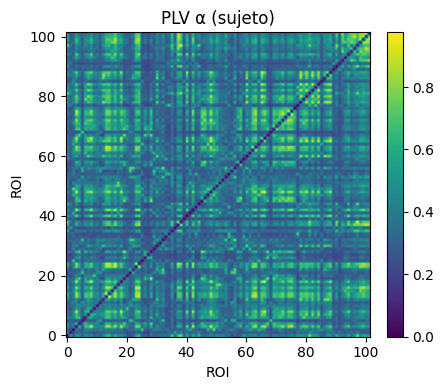

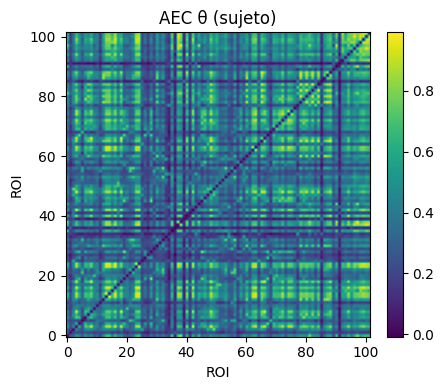

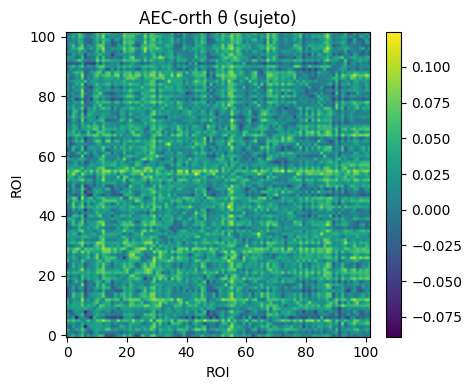

In [28]:
import numpy as np
from pathlib import Path
outdir = Path("out_quicklook"); outdir.mkdir(exist_ok=True)

import matplotlib.pyplot as plt

def plot_matrix(C, title, outfile=None, vmin=None, vmax=None):
    plt.figure(figsize=(5,4))
    im = plt.imshow(C, origin='lower', vmin=vmin, vmax=vmax, cmap='viridis')
    plt.colorbar(im, fraction=0.046, pad=0.04)
    plt.title(title)
    plt.xlabel("ROI"); plt.ylabel("ROI")
    plt.tight_layout()
    if outfile:
        plt.savefig(outfile, dpi=300, bbox_inches="tight")

# Ejemplos (usa tus nombres y rutas):
plot_matrix(subject_mats['alpha']['PLV'],      "PLV α (sujeto)",      "matrix_PLV_alpha_subject.png")
plot_matrix(subject_mats['theta']['AEC'],      "AEC θ (sujeto)",      "matrix_AEC_theta_subject.png")
plot_matrix(subject_mats['theta']['AEC-orth'], "AEC-orth θ (sujeto)", "matrix_AECorth_theta_subject.png")

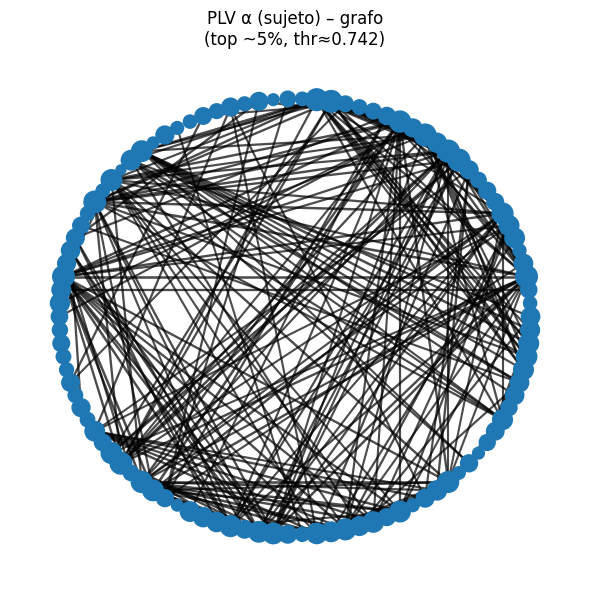

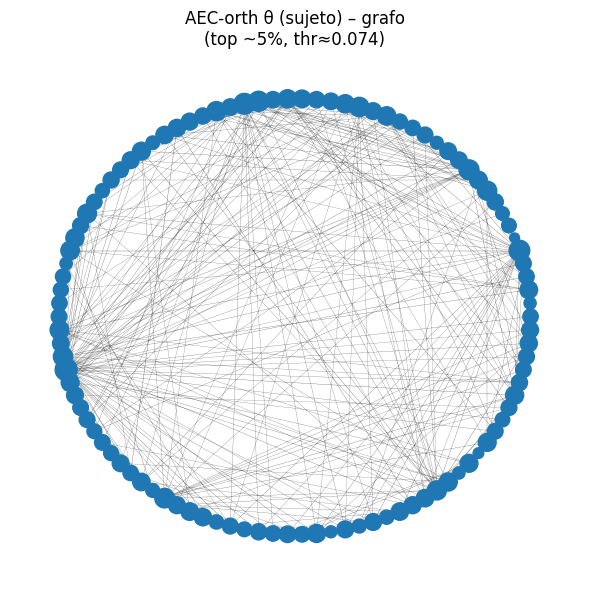

In [39]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

def edges_top_percent(C, top=0.05):
    R = C.shape[0]
    iu = np.triu_indices(R, 1)
    vals = np.asarray(C)[iu]
    thr = np.quantile(vals, 1.0 - top)
    mask = np.zeros_like(C, dtype=bool)
    mask[iu] = vals >= thr
    mask = mask | mask.T
    return mask, float(thr)

def graph_thresholded(C, roi_labels=None, top=0.05, title="", outfile=None, layout="circular"):
    C = np.asarray(C, float)
    mask, thr = edges_top_percent(C, top=top)
    G = nx.Graph()
    R = C.shape[0]
    for n in range(R):
        lab = roi_labels[n] if (roi_labels is not None and n < len(roi_labels)) else str(n)
        G.add_node(n, label=lab, strength=float(C[n].sum()))
    for i in range(R):
        for j in range(i+1, R):
            if mask[i, j]:
                G.add_edge(i, j, weight=float(C[i, j]))

    pos = nx.circular_layout(G) if layout == "circular" else nx.spring_layout(G, seed=0)

    plt.figure(figsize=(6, 6))
    strengths = np.array([G.nodes[n]['strength'] for n in G.nodes()])
    # usar np.ptp en NumPy 2.0 y proteger el caso “todos iguales”
    denom = np.ptp(strengths) if strengths.size else 0.0
    if denom < 1e-12:
        ns = np.full_like(strengths, 150.0, dtype=float)
    else:
        ns = 200.0 * (strengths - strengths.min()) / denom + 50.0

    nx.draw_networkx_nodes(G, pos, node_size=ns)
    widths = [2.0 * d["weight"] for _, _, d in G.edges(data=True)]
    nx.draw_networkx_edges(G, pos, width=widths, alpha=0.7)
    if roi_labels is not None:
        nx.draw_networkx_labels(G, pos, font_size=8)
    plt.title(f"{title}\n(top ~{int(top*100)}%, thr≈{thr:.3f})")
    plt.axis("off")
    plt.tight_layout()
    if outfile:
        plt.savefig(outfile, dpi=300, bbox_inches="tight")


# Ejemplos:
graph_thresholded(subject_mats['alpha']['PLV'],      title="PLV α (sujeto) – grafo",      outfile="graph_PLV_alpha_subject.png")
graph_thresholded(subject_mats['theta']['AEC-orth'], title="AEC-orth θ (sujeto) – grafo", outfile="graph_AECorth_theta_subject.png")

In [30]:
import numpy as np
import pandas as pd

def top_k_edges(C, roi_labels=None, k=20):
    R = C.shape[0]
    iu = np.triu_indices(R, 1)
    vals = C[iu]
    idx = np.argsort(vals)[::-1][:k]
    rows = []
    for r in idx:
        i, j = iu[0][r], iu[1][r]
        a = roi_labels[i] if roi_labels else f"ROI{i}"
        b = roi_labels[j] if roi_labels else f"ROI{j}"
        rows.append({"ROI_i": a, "ROI_j": b, "weight": float(vals[r])})
    return pd.DataFrame(rows)

df_top = top_k_edges(subject_mats['alpha']['PLV'], k=25)
print(df_top.head(10))
df_top.to_csv("top_edges_PLV_alpha_subject.csv", index=False)

   ROI_i  ROI_j    weight
0  ROI13  ROI14  0.975382
1  ROI38  ROI97  0.970624
2  ROI16  ROI24  0.964877
3  ROI65  ROI88  0.937077
4  ROI23  ROI24  0.936615
5   ROI8  ROI18  0.936183
6  ROI16  ROI42  0.933569
7  ROI82  ROI84  0.933460
8   ROI3  ROI42  0.931739
9  ROI18  ROI66  0.927832


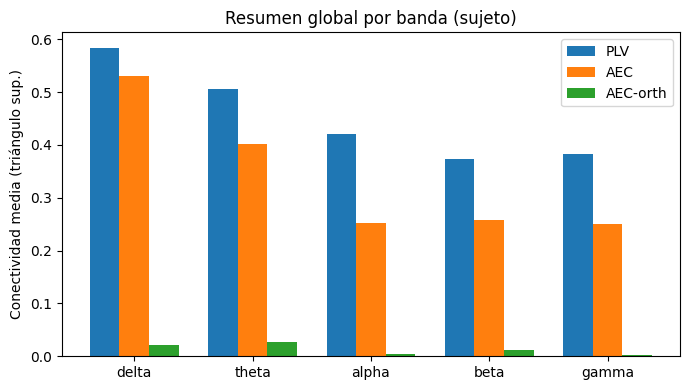

In [33]:
import numpy as np
import matplotlib.pyplot as plt

def global_mean_upper(C):
    R = C.shape[0]; iu = np.triu_indices(R, 1)
    return float(np.nanmean(C[iu]))

indices = ["PLV", "AEC", "AEC-orth"]
bands_order = ["delta","theta","alpha","beta","gamma"]

vals = {idx: [] for idx in indices}
for idx in indices:
    for b in bands_order:
        if b in subject_mats and idx in subject_mats[b]:
            vals[idx].append(global_mean_upper(subject_mats[b][idx]))
        else:
            vals[idx].append(np.nan)

# Barras por índice
x = np.arange(len(bands_order))
w = 0.25
plt.figure(figsize=(7,4))
for t, idx in enumerate(indices):
    plt.bar(x + (t-1)*w, vals[idx], width=w, label=idx)
plt.xticks(x, bands_order); plt.ylabel("Conectividad media (triángulo sup.)")
plt.title("Resumen global por banda (sujeto)")
plt.legend(); plt.tight_layout()
plt.savefig("bars_global_subject.png", dpi=300, bbox_inches="tight")

In [44]:
atlas = C.Atlas
scouts = atlas.Scouts

print("Tipo de atlas:", type(atlas))
print("Atlas name:", C.Atlas.Name)
print("Tipo de scouts:", type(scouts))

# Si es array, imprime forma y dtype
if isinstance(scouts, np.ndarray):
    print("scouts.shape:", scouts.shape)
    print("scouts.dtype:", scouts.dtype)
    first = scouts[0]
    print("Tipo del primer elemento:", type(first))
    print("Contenido del primer elemento:", first)

Tipo de atlas: <class 'scipy.io.matlab._mio5_params.mat_struct'>
Atlas name: Schaefer_100_17net
Tipo de scouts: <class 'numpy.ndarray'>
scouts.shape: (102,)
scouts.dtype: object
Tipo del primer elemento: <class 'scipy.io.matlab._mio5_params.mat_struct'>
Contenido del primer elemento: <scipy.io.matlab._mio5_params.mat_struct object at 0x000001F4EE337DA0>


In [49]:
import numpy as np
from collections import defaultdict

# ============================================================
# 1) Extract ROI labels from the BrainStorm atlas
# ============================================================

def extract_roi_labels_from_atlas(atlas):
    """
    Extract ROI labels from a BrainStorm-like atlas structure.

    Parameters
    ----------
    atlas : mat_struct
        Atlas object from the .mat file (e.g., C.Atlas).

    Returns
    -------
    roi_labels : list of str
        List of ROI names, one per row/column in your connectivity matrices.
    """
    scouts = atlas.Scouts

    # Normalize to a 1D array of objects (each "scout" is one ROI)
    if isinstance(scouts, (list, tuple)):
        scouts_arr = np.array(scouts, dtype=object).ravel()
    else:
        scouts_arr = np.atleast_1d(scouts).ravel()

    roi_labels = []
    for s in scouts_arr:
        # Typical case: MATLAB mat_struct with a .Label attribute
        if hasattr(s, 'Label'):
            roi_labels.append(str(s.Label))

        # Alternative: structured ndarray with a 'Label' field
        elif isinstance(s, np.ndarray) and s.dtype.names and ('Label' in s.dtype.names):
            lab = s['Label']
            # often this is a 1-element array
            if isinstance(lab, np.ndarray):
                lab = lab[0]
            roi_labels.append(str(lab))

        # Fallback: generic name if label is not clearly accessible
        else:
            roi_labels.append("ROI_" + str(len(roi_labels)))

    return roi_labels


# Assuming the MEG data / atlas is stored in C (already loaded with scipy.io.loadmat)
atlas = C.Atlas
roi_labels = extract_roi_labels_from_atlas(atlas)

print("Number of ROIs:", len(roi_labels))
print("First labels:", roi_labels[:20])

n_rois = len(roi_labels)

# ============================================================
# 2) Map ROIs to functional networks (Default, Control, SomMot, etc.)
# ============================================================

def get_network_prefix(label: str) -> str:
    """
    Extract the network prefix from a ROI label.

    Examples
    --------
    "DefaultA_PFCd_1 L" -> "DefaultA"
    "DorsAttnB_FEF_1 R" -> "DorsAttnB"
    "SomMotA_1 L"       -> "SomMotA"
    "Background+FreeSurfer_Defined_Medial_Wall L" -> "Background+FreeSurfer"
    """
    # Take the part before the first underscore
    first = label.split("_")[0]
    # In case there is an extra space, keep only the first "word"
    first = first.split()[0]
    return first

# Prefix for each ROI
prefixes = [get_network_prefix(lab) for lab in roi_labels]

unique_prefixes = sorted(set(prefixes))
print("\nPrefixes found in atlas:")
print(unique_prefixes)

# Map fine-grained prefixes to macro functional networks
# (following a Yeo/Schaefer-like spirit)
network_map = {
    # Default Mode sub-networks
    "DefaultA": "Default",
    "DefaultB": "Default",
    "DefaultC": "Default",

    # Frontoparietal / Control
    "ContA": "Control",
    "ContB": "Control",
    "ContC": "Control",

    # Dorsal Attention
    "DorsAttnA": "DorsAttn",
    "DorsAttnB": "DorsAttn",

    # Salience / Ventral Attention
    "SalVentAttnA": "SalVentAttn",
    "SalVentAttnB": "SalVentAttn",

    # Somatomotor
    "SomMotA": "SomMot",

    # Limbic
    "LimbicA": "Limbic",
    "LimbicB": "Limbic",

    # Temporo-parietal
    "TempPar": "TempPar",

    # Medial Wall / Background (usually excluded from analyses)
    "Background+FreeSurfer": "Background",
}

def map_prefix_to_network(prefix: str) -> str:
    """
    Map a prefix (e.g. 'DefaultA') to its macro-network name (e.g. 'Default').
    If the prefix is not in network_map, keep it as its own group.
    """
    return network_map.get(prefix, prefix)

# Network label for each ROI
networks = [map_prefix_to_network(p) for p in prefixes]
unique_networks = sorted(set(networks))
print("\nFunctional networks (grouped):")
print(unique_networks)

# ============================================================
# 3) Build boolean masks per functional network
# ============================================================

network_to_mask = {}
for net in unique_networks:
    mask = np.array([n == net for n in networks], dtype=bool)
    network_to_mask[net] = mask

# Print network sizes
print("\nSize of each network (number of ROIs):")
for net in unique_networks:
    print(f"{net:15s}: {np.sum(network_to_mask[net])} ROIs")

# Helper to show some example labels per network
def labels_from_mask(labels, mask, max_print=10):
    """
    Return up to max_print labels that belong to a given boolean mask.
    """
    return [lab for lab, m in zip(labels, mask) if m][:max_print]

print("\nExample ROIs per network:")
for net in unique_networks:
    print(f"\n{net}:")
    print(labels_from_mask(roi_labels, network_to_mask[net], max_print=5))

# Optional sanity check: are all non-background ROIs assigned to some network?
is_background = np.array([net == "Background" for net in networks])
mask_any_network = np.zeros(n_rois, dtype=bool)
for net, mask in network_to_mask.items():
    if net == "Background":
        continue
    mask_any_network |= mask

print("\nSanity check:")
print("Total ROIs:", n_rois)
print("Background ROIs:", is_background.sum())
print("Non-background ROIs:", n_rois - is_background.sum())
print("Non-background covered by some network:", mask_any_network[~is_background].sum())
print("Any non-background ROI without network?:", np.any(~is_background & ~mask_any_network))

# ============================================================
# 4) Functions to compute mean intra-network and inter-network connectivity
# ============================================================

def mean_intra(C, mask):
    """
    Compute mean intra-network connectivity for matrix C and a boolean ROI mask.

    Parameters
    ----------
    C : (n_rois, n_rois) array
        Connectivity matrix (e.g., PLV, AEC-orth).
    mask : (n_rois,) bool array
        True for ROIs belonging to the network of interest.

    Returns
    -------
    float
        Mean of the upper triangle (excluding diagonal) of the submatrix.
        NaN if the network has fewer than 2 ROIs.
    """
    idx = np.where(mask)[0]
    if len(idx) <= 1:
        return np.nan
    sub = C[np.ix_(idx, idx)]
    iu = np.triu_indices(len(idx), 1)
    return float(np.nanmean(sub[iu]))

def mean_inter(C, maskA, maskB):
    """
    Compute mean inter-network connectivity between two ROI masks.

    Parameters
    ----------
    C : (n_rois, n_rois) array
        Connectivity matrix.
    maskA, maskB : (n_rois,) bool arrays
        Masks for network A and network B.

    Returns
    -------
    float
        Mean connectivity between all ROIs in A and all ROIs in B.
        NaN if one of the masks is empty.
    """
    iA = np.where(maskA)[0]
    iB = np.where(maskB)[0]
    if len(iA) == 0 or len(iB) == 0:
        return np.nan
    sub = C[np.ix_(iA, iB)]
    return float(np.nanmean(sub))

# ============================================================
# 5) Example: use your connectivity matrices and compute summaries
# ============================================================

# subject_mats should already contain your subject's connectivity:
# subject_mats['alpha']['PLV']      -> PLV matrix in alpha band
# subject_mats['theta']['AEC-orth'] -> AEC-orth matrix in theta band
C_alpha_plv  = subject_mats['alpha']['PLV']
C_theta_aeco = subject_mats['theta']['AEC-orth']

print("\nConnectivity matrix shapes:")
print("C_alpha_plv  :", C_alpha_plv.shape)
print("C_theta_aeco :", C_theta_aeco.shape)

# --- Example 1: intra-network PLV in alpha band ---
print("\n--- PLV (alpha) intra-network connectivity ---")
for net in unique_networks:
    if net == "Background":
        continue  # ignore medial wall
    val = mean_intra(C_alpha_plv, network_to_mask[net])
    print(f"Intra {net:15s}: {val:.4f}")

# --- Example 2: inter-network AEC-orth in theta band ---
print("\n--- AEC-orth (theta) inter-network connectivity (examples) ---")
pairs_to_check = [
    ("Default", "DorsAttn"),
    ("Default", "Control"),
    ("Default", "SalVentAttn"),
    ("SomMot",  "SalVentAttn"),
    ("Control", "DorsAttn"),
]

for netA, netB in pairs_to_check:
    if netA in network_to_mask and netB in network_to_mask:
        val = mean_inter(C_theta_aeco, network_to_mask[netA], network_to_mask[netB])
        print(f"Inter {netA:10s} – {netB:10s}: {val:.4f}")
    else:
        print(f"Pair {netA}-{netB} not found in networks.")


Number of ROIs: 102
First labels: ['Background+FreeSurfer_Defined_Medial_Wall L', 'Background+FreeSurfer_Defined_Medial_Wall R', 'ContA_IPS_1 L', 'ContA_IPS_1 R', 'ContA_PFCl_1 L', 'ContA_PFCl_1 R', 'ContA_PFCl_2 L', 'ContA_PFCl_2 R', 'ContB_IPL_1 R', 'ContB_PFCld_1 R', 'ContB_PFClv_1 L', 'ContB_PFClv_1 R', 'ContB_Temp_1 R', 'ContC_Cingp_1 L', 'ContC_Cingp_1 R', 'ContC_pCun_1 L', 'ContC_pCun_1 R', 'ContC_pCun_2 L', 'DefaultA_IPL_1 R', 'DefaultA_PFCd_1 L']

Prefixes found in atlas:
['Background+FreeSurfer', 'ContA', 'ContB', 'ContC', 'DefaultA', 'DefaultB', 'DefaultC', 'DorsAttnA', 'DorsAttnB', 'LimbicA', 'LimbicB', 'SalVentAttnA', 'SalVentAttnB', 'SomMotA', 'SomMotB', 'TempPar', 'VisCent', 'VisPeri']

Functional networks (grouped):
['Background', 'Control', 'Default', 'DorsAttn', 'Limbic', 'SalVentAttn', 'SomMot', 'SomMotB', 'TempPar', 'VisCent', 'VisPeri']

Size of each network (number of ROIs):
Background     : 2 ROIs
Control        : 16 ROIs
Default        : 21 ROIs
DorsAttn       :